# 04 - Evaluate Test Split

Notebook này đánh giá checkpoint từ notebook 03 trên test split đã tạo ở notebook 02.

Output phục vụ phần Evaluation trong CK:

- `eval_summary.json`
- `eval_metrics.csv`
- `per_subset_metrics.csv`
- `prediction_vs_ground_truth.png`

Metrics chính: MSE, MAE, RMSE trên action đã denormalize. MSE/MAE/RMSE càng thấp càng tốt.


In [1]:
import csv
import json
import math
import random
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, Subset
from tqdm.auto import tqdm

print('torch:', torch.__version__)
print('cuda available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('gpu:', torch.cuda.get_device_name(0))


torch: 2.10.0+cu128
cuda available: True
gpu: Tesla T4


In [2]:
SEED = 42
BATCH_SIZE = 4096
NUM_WORKERS = 2
DENOISING_STEPS = 4
USE_AMP = True

# None = evaluate toàn bộ test split. Đổi thành số nhỏ, ví dụ 100_000, chỉ khi debug nhanh.
MAX_EVAL_SAMPLES = None

OUTPUT_ROOT = Path('/kaggle/working/gr00t_eval_results')
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)
print('output:', OUTPUT_ROOT)


device: cuda
output: /kaggle/working/gr00t_eval_results


In [3]:
def find_root(folder_name: str, required_files: list[str]) -> Path:
    candidates = []
    for base in [Path('/kaggle/input'), Path('/kaggle/working')]:
        if not base.exists():
            continue
        for path in base.rglob(folder_name):
            if not path.is_dir():
                continue
            if all((path / name).exists() for name in required_files):
                candidates.append(path)
    if not candidates:
        raise FileNotFoundError(
            f'Không tìm thấy {folder_name}. Hãy Add Input output notebook cần thiết trước khi chạy.'
        )
    return sorted(candidates, key=lambda p: (0 if str(p).startswith('/kaggle/input') else 1, str(p)))[0]


PREPARED_ROOT = find_root('gr00t_prepared_3subsets', [
    'prepare_report.json',
    'actions_test.npy',
    'states_test.npy',
    'test_samples.parquet',
])
RUN_ROOT = find_root('gr00t_dit_runs', [
    'config.json',
    'checkpoint_last.pt',
    'train_summary.json',
])

print('PREPARED_ROOT:', PREPARED_ROOT)
print('RUN_ROOT:', RUN_ROOT)

with open(PREPARED_ROOT / 'prepare_report.json', 'r', encoding='utf-8') as f:
    prepare_report = json.load(f)
with open(RUN_ROOT / 'config.json', 'r', encoding='utf-8') as f:
    train_config = json.load(f)
with open(RUN_ROOT / 'train_summary.json', 'r', encoding='utf-8') as f:
    train_summary = json.load(f)

print(json.dumps({
    'subsets_found': prepare_report.get('subsets_found'),
    'num_test_samples': prepare_report.get('num_test_samples'),
    'action_dim': prepare_report.get('action_dim'),
    'state_dim': prepare_report.get('state_dim'),
    'train_full_epoch_completed': train_summary.get('full_epoch_completed'),
    'train_global_steps': train_summary.get('global_steps'),
}, ensure_ascii=False, indent=2))

assert prepare_report.get('action_cols') == ['action']
assert prepare_report.get('state_cols') == ['observation.state']
assert train_summary.get('full_epoch_completed') is True, 'Notebook 03 chưa train full epoch.'


PREPARED_ROOT: /kaggle/input/datasets/kimthanh211005/gr00t-prepared-3subsets/gr00t_prepared_3subsets
RUN_ROOT: /kaggle/input/datasets/kimthanh211005/output-notebook-3/gr00t_dit_runs
{
  "subsets_found": [
    "gr1_arms_only.CanSort",
    "gr1_arms_waist.CanToDrawer",
    "gr1_arms_waist.CupToDrawer"
  ],
  "num_test_samples": 1240153,
  "action_dim": 44,
  "state_dim": 44,
  "train_full_epoch_completed": true,
  "train_global_steps": 4835
}


In [4]:
class SinusoidalTimeEmbedding(nn.Module):
    def __init__(self, dim: int):
        super().__init__()
        self.dim = dim

    def forward(self, t: torch.Tensor) -> torch.Tensor:
        half = self.dim // 2
        freqs = torch.exp(
            -math.log(10000) * torch.arange(half, device=t.device, dtype=t.dtype) / max(half - 1, 1)
        )
        args = t[:, None] * freqs[None, :]
        emb = torch.cat([torch.sin(args), torch.cos(args)], dim=-1)
        if self.dim % 2 == 1:
            emb = F.pad(emb, (0, 1))
        return emb


class MiniDiTActionHead(nn.Module):
    def __init__(self, state_dim: int, action_dim: int, hidden_dim: int, num_layers: int, num_heads: int, dropout: float):
        super().__init__()
        self.action_proj = nn.Linear(action_dim, hidden_dim)
        self.state_proj = nn.Linear(state_dim, hidden_dim)
        self.time_embed = nn.Sequential(
            SinusoidalTimeEmbedding(hidden_dim),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
        )
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_dim,
            nhead=num_heads,
            dim_feedforward=hidden_dim * 4,
            dropout=dropout,
            activation='gelu',
            batch_first=True,
            norm_first=True,
        )
        self.blocks = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.norm = nn.LayerNorm(hidden_dim)
        self.out = nn.Linear(hidden_dim, action_dim)

    def forward(self, noisy_action: torch.Tensor, state: torch.Tensor, tau: torch.Tensor) -> torch.Tensor:
        time = self.time_embed(tau)
        action_token = self.action_proj(noisy_action) + time
        state_token = self.state_proj(state) + time
        tokens = torch.stack([action_token, state_token], dim=1)
        tokens = self.blocks(tokens)
        return self.out(self.norm(tokens[:, 0]))


checkpoint = torch.load(RUN_ROOT / 'checkpoint_last.pt', map_location='cpu', weights_only=False)
ckpt_config = checkpoint['config']

model = MiniDiTActionHead(
    state_dim=int(ckpt_config['state_dim']),
    action_dim=int(ckpt_config['action_dim']),
    hidden_dim=int(ckpt_config['hidden_dim']),
    num_layers=int(ckpt_config['num_layers']),
    num_heads=int(ckpt_config['num_heads']),
    dropout=float(ckpt_config['dropout']),
).to(device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

normalization = checkpoint['normalization']
state_mean = np.asarray(normalization['state_mean'], dtype=np.float32)
state_std = np.asarray(normalization['state_std'], dtype=np.float32)
action_mean = np.asarray(normalization['action_mean'], dtype=np.float32)
action_std = np.asarray(normalization['action_std'], dtype=np.float32)

state_mean_t = torch.from_numpy(state_mean).to(device)
state_std_t = torch.from_numpy(state_std).to(device)
action_mean_t = torch.from_numpy(action_mean).to(device)
action_std_t = torch.from_numpy(action_std).to(device)

print('Loaded checkpoint global_step:', checkpoint.get('global_step'))
print('Model params:', sum(p.numel() for p in model.parameters()))


/tmp/ipykernel_23/2442243357.py:38: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.blocks = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)


Loaded checkpoint global_step: 4835
Model params: 3325484


In [5]:
actions_test = np.load(PREPARED_ROOT / 'actions_test.npy', mmap_mode='r')
states_test = np.load(PREPARED_ROOT / 'states_test.npy', mmap_mode='r')
test_samples = pd.read_parquet(PREPARED_ROOT / 'test_samples.parquet')

assert len(actions_test) == len(states_test) == len(test_samples)
assert actions_test.shape[1] == ckpt_config['action_dim']
assert states_test.shape[1] == ckpt_config['state_dim']

print('actions_test:', actions_test.shape, actions_test.dtype)
print('states_test:', states_test.shape, states_test.dtype)
print('test_samples:', test_samples.shape)
print(test_samples['__subset'].value_counts() if '__subset' in test_samples.columns else 'No subset column')


class EvalDataset(Dataset):
    def __init__(self, states, actions, state_mean, state_std, action_mean, action_std):
        self.states = states
        self.actions = actions
        self.state_mean = state_mean
        self.state_std = state_std
        self.action_mean = action_mean
        self.action_std = action_std

    def __len__(self):
        return len(self.actions)

    def __getitem__(self, idx):
        state = np.asarray(self.states[idx], dtype=np.float32)
        action = np.asarray(self.actions[idx], dtype=np.float32)
        state_norm = (state - self.state_mean) / self.state_std
        action_norm = (action - self.action_mean) / self.action_std
        return int(idx), torch.from_numpy(state_norm), torch.from_numpy(action_norm)


base_dataset = EvalDataset(states_test, actions_test, state_mean, state_std, action_mean, action_std)
if MAX_EVAL_SAMPLES is not None and MAX_EVAL_SAMPLES < len(base_dataset):
    rng = np.random.default_rng(SEED)
    eval_indices = np.sort(rng.choice(len(base_dataset), size=int(MAX_EVAL_SAMPLES), replace=False))
    eval_dataset = Subset(base_dataset, eval_indices.tolist())
else:
    eval_dataset = base_dataset

eval_loader = DataLoader(
    eval_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

print('Eval samples:', len(eval_dataset))
print('Eval batches:', len(eval_loader))


actions_test: (1240153, 44) float32
states_test: (1240153, 44) float32
test_samples: (1240153, 12)
__subset
gr1_arms_waist.CanToDrawer    651120
gr1_arms_waist.CupToDrawer    535918
gr1_arms_only.CanSort          53115
Name: count, dtype: int64
Eval samples: 1240153
Eval batches: 303


In [6]:
@torch.no_grad()
def sample_actions(state_norm: torch.Tensor, steps: int) -> torch.Tensor:
    pred = torch.randn(state_norm.size(0), int(ckpt_config['action_dim']), device=state_norm.device)
    dt = 1.0 / steps
    for step in range(steps):
        tau = torch.full((state_norm.size(0),), step / steps, device=state_norm.device)
        vector_field = model(pred, state_norm, tau)
        # Training target is noise - action. Starting from noise, subtract the vector field to move toward action.
        pred = pred - dt * vector_field
    return pred


def new_metric_bucket():
    return {'sq_sum': 0.0, 'abs_sum': 0.0, 'count': 0, 'samples': 0}


overall = new_metric_bucket()
per_subset = {}
flow_loss_sum = 0.0
flow_loss_batches = 0
preview_pred = []
preview_true = []
preview_limit = 2048

start_time = time.time()
torch.manual_seed(SEED)

for idx, state_norm, action_norm in tqdm(eval_loader, desc='Evaluating'):
    idx_np = idx.numpy()
    state_norm = state_norm.to(device, non_blocking=True)
    action_norm = action_norm.to(device, non_blocking=True)

    with torch.cuda.amp.autocast(enabled=USE_AMP and torch.cuda.is_available()):
        tau = torch.rand(action_norm.size(0), device=device)
        noise = torch.randn_like(action_norm)
        noisy = tau[:, None] * action_norm + (1.0 - tau[:, None]) * noise
        target_vector_field = noise - action_norm
        flow_pred = model(noisy, state_norm, tau)
        flow_loss = F.mse_loss(flow_pred, target_vector_field)
        pred_norm = sample_actions(state_norm, DENOISING_STEPS)

    pred = pred_norm.float() * action_std_t + action_mean_t
    target = action_norm.float() * action_std_t + action_mean_t
    diff = pred - target
    sq = diff.square().detach().cpu().numpy()
    ab = diff.abs().detach().cpu().numpy()

    overall['sq_sum'] += float(sq.sum())
    overall['abs_sum'] += float(ab.sum())
    overall['count'] += int(sq.size)
    overall['samples'] += int(sq.shape[0])
    flow_loss_sum += float(flow_loss.detach().cpu())
    flow_loss_batches += 1

    subset_values = test_samples.iloc[idx_np]['__subset'].to_numpy() if '__subset' in test_samples.columns else np.array(['unknown'] * len(idx_np))
    for subset in np.unique(subset_values):
        mask = subset_values == subset
        bucket = per_subset.setdefault(str(subset), new_metric_bucket())
        bucket['sq_sum'] += float(sq[mask].sum())
        bucket['abs_sum'] += float(ab[mask].sum())
        bucket['count'] += int(sq[mask].size)
        bucket['samples'] += int(mask.sum())

    if len(preview_pred) < preview_limit:
        take = min(preview_limit - len(preview_pred), pred.size(0))
        preview_pred.extend(pred[:take, 0].detach().cpu().tolist())
        preview_true.extend(target[:take, 0].detach().cpu().tolist())

elapsed_sec = time.time() - start_time
print('Evaluation elapsed seconds:', round(elapsed_sec, 2))


Evaluating:   0%|          | 0/303 [00:00<?, ?it/s]

/tmp/ipykernel_23/1794131308.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP and torch.cuda.is_available()):


Evaluation elapsed seconds: 20.47


In [7]:
def finalize_metrics(bucket):
    mse = bucket['sq_sum'] / max(bucket['count'], 1)
    mae = bucket['abs_sum'] / max(bucket['count'], 1)
    rmse = math.sqrt(mse)
    return {
        'samples': int(bucket['samples']),
        'values': int(bucket['count']),
        'mse': float(mse),
        'mae': float(mae),
        'rmse': float(rmse),
    }


overall_metrics = finalize_metrics(overall)
overall_metrics['flow_matching_test_loss'] = flow_loss_sum / max(flow_loss_batches, 1)
overall_metrics['denoising_steps'] = DENOISING_STEPS

per_subset_rows = []
for subset, bucket in sorted(per_subset.items()):
    row = {'subset': subset, **finalize_metrics(bucket)}
    per_subset_rows.append(row)

metrics_df = pd.DataFrame([{
    'model': 'mini_dit_from_scratch',
    'test_data': 'held_out_episodes_3_gr1_subsets',
    **overall_metrics,
}])
per_subset_df = pd.DataFrame(per_subset_rows)

metrics_df.to_csv(OUTPUT_ROOT / 'eval_metrics.csv', index=False)
per_subset_df.to_csv(OUTPUT_ROOT / 'per_subset_metrics.csv', index=False)

print('Overall metrics:')
display(metrics_df)
print('Per-subset metrics:')
display(per_subset_df)


Overall metrics:


,model,test_data,samples,values,mse,mae,rmse,flow_matching_test_loss,denoising_steps
0,mini_dit_from_scratch,held_out_episodes_3_gr1_subsets,1240153,54566732,0.021758,0.023373,0.147507,0.079416,4


Per-subset metrics:


,subset,samples,values,mse,mae,rmse
0,gr1_arms_only.CanSort,53115,2337060,0.010471,0.044375,0.102327
1,gr1_arms_waist.CanToDrawer,651120,28649280,0.016488,0.020613,0.128405
2,gr1_arms_waist.CupToDrawer,535918,23580392,0.029281,0.024646,0.171116


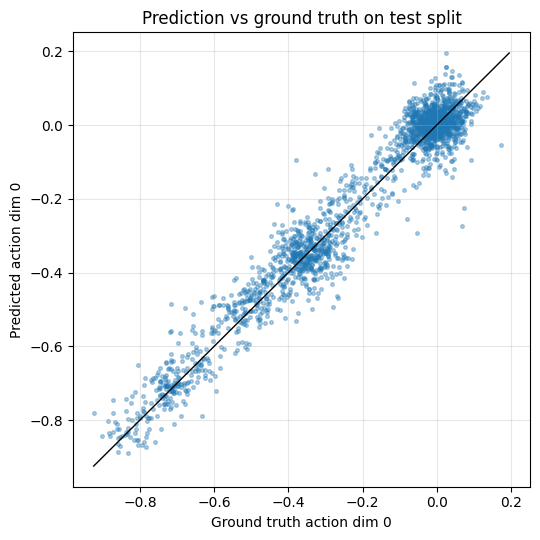

{
  "eval_samples": 1240153,
  "mse": 0.021758461503123223,
  "mae": 0.023373399816231835,
  "rmse": 0.1475074964302602,
  "flow_matching_test_loss": 0.07941553353181373,
  "elapsed_sec": 20.47
}
Saved artifacts:
- eval_metrics.csv 0.0 MB
- eval_summary.json 0.006 MB
- per_subset_metrics.csv 0.0 MB
- prediction_vs_ground_truth.png 0.135 MB


In [8]:
plt.figure(figsize=(5.5, 5.5))
plt.scatter(preview_true, preview_pred, s=7, alpha=0.35)
min_v = min(min(preview_true), min(preview_pred))
max_v = max(max(preview_true), max(preview_pred))
plt.plot([min_v, max_v], [min_v, max_v], color='black', linewidth=1)
plt.xlabel('Ground truth action dim 0')
plt.ylabel('Predicted action dim 0')
plt.title('Prediction vs ground truth on test split')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_ROOT / 'prediction_vs_ground_truth.png', dpi=160)
plt.show()

eval_summary = {
    'status': 'completed',
    'objective': 'Evaluate mini DiT/action head checkpoint on held-out test split.',
    'prepared_root': str(PREPARED_ROOT),
    'run_root': str(RUN_ROOT),
    'output_root': str(OUTPUT_ROOT),
    'max_eval_samples': MAX_EVAL_SAMPLES,
    'eval_samples': int(overall_metrics['samples']),
    'denoising_steps': DENOISING_STEPS,
    'batch_size': BATCH_SIZE,
    'metrics': overall_metrics,
    'per_subset_metrics': per_subset_rows,
    'train_summary': train_summary,
    'prepare_report': prepare_report,
    'elapsed_sec': round(elapsed_sec, 2),
    'artifacts': [
        'eval_summary.json',
        'eval_metrics.csv',
        'per_subset_metrics.csv',
        'prediction_vs_ground_truth.png',
    ],
}

with open(OUTPUT_ROOT / 'eval_summary.json', 'w', encoding='utf-8') as f:
    json.dump(eval_summary, f, ensure_ascii=False, indent=2)

print(json.dumps({
    'eval_samples': eval_summary['eval_samples'],
    'mse': overall_metrics['mse'],
    'mae': overall_metrics['mae'],
    'rmse': overall_metrics['rmse'],
    'flow_matching_test_loss': overall_metrics['flow_matching_test_loss'],
    'elapsed_sec': eval_summary['elapsed_sec'],
}, indent=2))
print('Saved artifacts:')
for path in sorted(OUTPUT_ROOT.iterdir()):
    print('-', path.name, round(path.stat().st_size / (1024 ** 2), 3), 'MB')


## Sau Khi Chạy Xong

Kiểm tra tab Output có thư mục:

```text
gr00t_eval_results/
  eval_summary.json
  eval_metrics.csv
  per_subset_metrics.csv
  prediction_vs_ground_truth.png
```

Các số quan trọng để đưa vào báo cáo/slides là `mse`, `mae`, `rmse`, và bảng per-subset trong `per_subset_metrics.csv`.

Save Version output này rồi dùng tiếp cho notebook 05 ablation hoặc notebook 06 collect results.
